# Looking into some properties of Kp

In [1]:
import sys
dir_path = '/Users/henry/Desktop/SWxResearch/KpAp-forecast-verification'
if dir_path not in sys.path:
    sys.path.insert(0, dir_path)

import os
os.chdir(dir_path)

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import h5py


## Average Kp for each year

In [44]:
df_raw_Kp = pd.read_csv('processed_data/3hour_Kp.csv')
dates = df_raw_Kp['Datetime']
print(dates)
Kp_vals = df_raw_Kp['Kp']

0         1932-01-01 00:00:00
1         1932-01-01 03:00:00
2         1932-01-01 06:00:00
3         1932-01-01 09:00:00
4         1932-01-01 12:00:00
                 ...         
274315    2025-11-17 09:00:00
274316    2025-11-17 12:00:00
274317    2025-11-17 15:00:00
274318    2025-11-17 18:00:00
274319    2025-11-17 21:00:00
Name: Datetime, Length: 274320, dtype: object


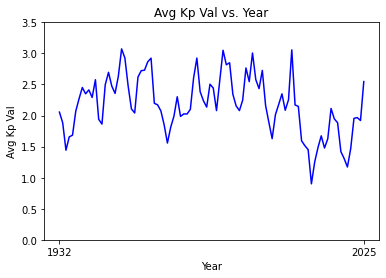

In [54]:
df = pd.DataFrame({'year': [d[:4] for d in dates], 'kp': Kp_vals})
Kp_vals_by_year = df.groupby('year')['kp'].apply(list)
year_list = Kp_vals_by_year.index.to_list()

avg_Kp_vals_by_year = []
for year in Kp_vals_by_year:
    avg_Kp_vals_by_year.append(np.mean(year))


plt.plot(avg_Kp_vals_by_year, 'b')
plt.xlabel('Year')
plt.ylabel('Avg Kp Val')
plt.title('Avg Kp Val vs. Year')
plt.ylim(0, 3.5)
plt.xticks(ticks=[0, 2025-1932],labels=[year_list[0], year_list[-1]])
plt.show()



## Average Kp for each month


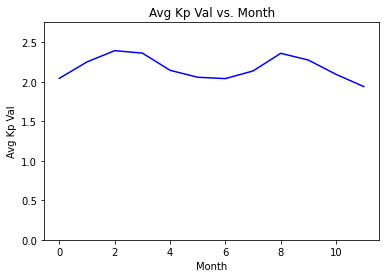

In [56]:
df = pd.DataFrame({'month': [d[5:7] for d in dates], 'kp': Kp_vals})
Kp_vals_by_month = df.groupby('month')['kp'].apply(list)
month_list = Kp_vals_by_month.index.to_list()

avg_Kp_vals_by_month = []
for month in Kp_vals_by_month:
    avg_Kp_vals_by_month.append(np.mean(month))


plt.plot(avg_Kp_vals_by_month, 'b')
plt.xlabel('Month')
plt.ylabel('Avg Kp Val')
plt.ylim(0, 2.75)
plt.title('Avg Kp Val vs. Month')
#plt.xticks(ticks=[0, 2025-1932],labels=['1932', '2025'])
plt.show()



## Average Kp for each time of day

tod
00:00:00    [3.333, 3.667, 3.333, 2.0, 0.0, 1.333, 0.0, 1....
03:00:00    [2.667, 3.667, 3.333, 0.333, 0.0, 0.667, 1.0, ...
06:00:00    [2.333, 3.333, 3.0, 1.0, 0.333, 0.333, 1.333, ...
09:00:00    [2.667, 3.667, 1.0, 0.0, 0.667, 1.0, 0.333, 3....
12:00:00    [3.333, 3.333, 2.333, 1.0, 0.333, 1.333, 0.333...
15:00:00    [2.667, 4.667, 1.667, 1.333, 1.333, 1.667, 1.0...
18:00:00    [3.333, 3.0, 2.667, 1.333, 1.333, 1.333, 4.0, ...
21:00:00    [3.333, 5.0, 2.0, 1.0, 2.0, 1.667, 4.333, 4.66...
Name: kp, dtype: object


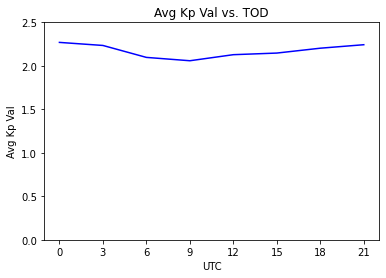

In [ ]:
df = pd.DataFrame({'tod': [d[11:] for d in dates], 'kp': Kp_vals})
Kp_vals_by_tod = df.groupby('tod')['kp'].apply(list)
tod_list = Kp_vals_by_tod.index.to_list()

avg_Kp_vals_by_tod = []
for tod in Kp_vals_by_tod:
    avg_Kp_vals_by_tod.append(np.mean(tod))


plt.plot(avg_Kp_vals_by_tod, 'b')
plt.xlabel('UTC')
plt.ylabel('Avg Kp Val')
plt.ylim(0, 2.5)
plt.title('Avg Kp Val vs. TOD')
plt.xticks(ticks=[i for i in range(8)],labels=[3*i for i in range(8)])
plt.show()

